<a href="https://colab.research.google.com/github/NitinKarthik01/AIML_MSIS/blob/main/Project_Breast_cancer_using_DT_and_LR.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# build ML model
# take breast cancer dataset from scikit learn (begnin and normal classification)
# do preprocessing
# build two models - decision tree and linear regression/Logistic Regression
# confusion matrix(only for testing), accuracy, precision, recall. f1 score
# conclude which model is better
# training - 70%, testing - 30%
#sammera.p@manipal.edu

In [69]:
from sklearn.datasets import load_breast_cancer
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

cancer = load_breast_cancer(as_frame=True)
df =cancer.frame

display(df.head())


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


In [130]:
missing = df.isnull().sum()
display(missing)

,0
mean radius,0
mean texture,0
mean perimeter,0
mean area,0
mean smoothness,0
mean compactness,0
mean concavity,0
mean concave points,0
mean symmetry,0
mean fractal dimension,0


# No Missing Values

In [122]:
categorical_cols = df.select_dtypes(include='object').columns.tolist()
numerical_cols = df.select_dtypes(include=np.number).columns.tolist()

print(f"\nCategorical Columns ({len(categorical_cols)}):")
print(categorical_cols if categorical_cols else "None")

print(f"\nNumerical Columns ({len(numerical_cols)}):")
print(numerical_cols if numerical_cols else "None")




Categorical Columns (0):
None

Numerical Columns (31):
['mean radius', 'mean texture', 'mean perimeter', 'mean area', 'mean smoothness', 'mean compactness', 'mean concavity', 'mean concave points', 'mean symmetry', 'mean fractal dimension', 'radius error', 'texture error', 'perimeter error', 'area error', 'smoothness error', 'compactness error', 'concavity error', 'concave points error', 'symmetry error', 'fractal dimension error', 'worst radius', 'worst texture', 'worst perimeter', 'worst area', 'worst smoothness', 'worst compactness', 'worst concavity', 'worst concave points', 'worst symmetry', 'worst fractal dimension', 'target']


## All are Numerical Columns : Encoding is not needed

#***Logitic Regression Model***

Min-Max Scaling on Training Set


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,0.296244,0.277308,0.283818,0.177894,0.167807,0.151976,0.067502,0.066054,0.163374,0.122999,...,0.243476,0.278252,0.217071,0.124628,0.115640,0.163881,0.173124,0.218396,0.154741,0.128009
1,0.278123,0.225905,0.269406,0.164378,0.085638,0.184474,0.189597,0.139165,0.136145,0.174179,...,0.204006,0.285981,0.190636,0.101355,0.154940,0.242126,0.366172,0.325762,0.095210,0.180061
2,0.342769,0.144403,0.355879,0.208401,0.402319,0.562359,0.339738,0.313121,0.490657,0.507582,...,0.284409,0.168443,0.303035,0.145296,0.364200,0.364306,0.356321,0.402032,0.248768,0.314005
3,0.255595,0.223876,0.243936,0.148460,0.167509,0.117389,0.090745,0.118141,0.353444,0.141323,...,0.190118,0.265991,0.184637,0.093539,0.207437,0.128688,0.195262,0.298803,0.287601,0.122499
4,0.290367,0.457220,0.277183,0.172831,0.296858,0.164681,0.069681,0.121421,0.265350,0.169545,...,0.243842,0.454957,0.219053,0.125595,0.294203,0.129905,0.116117,0.260305,0.212300,0.122838
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
393,0.058622,0.166723,0.074558,0.031580,0.350084,0.457914,0.201640,0.142744,0.392419,0.839090,...,0.038557,0.097281,0.041025,0.015085,0.287641,0.231612,0.158734,0.173657,0.135817,0.452357
394,0.193398,0.291512,0.191424,0.103879,0.512340,0.281899,0.165651,0.173211,0.338494,0.320977,...,0.163073,0.459488,0.157694,0.073963,0.638352,0.256402,0.318021,0.441945,0.244628,0.304595
395,0.323179,0.240446,0.299372,0.198318,0.017643,0.025238,0.016987,0.031064,0.182061,0.080034,...,0.227761,0.230011,0.203091,0.114381,0.032227,0.017752,0.042794,0.120936,0.176030,0.052221
396,0.307997,0.335137,0.305223,0.184116,0.431064,0.321622,0.263824,0.321223,0.268019,0.326032,...,0.305606,0.500533,0.302018,0.160207,0.583668,0.356891,0.450410,0.662917,0.318155,0.427772


 
 
 
Evaluation Metrics for Training Data
Accuracy :  0.9673366834170855
Precision :  0.9684120154843336
Recall :  0.9673366834170855
F1 Score :  0.9670636748565565
 
 
Evaluation Metrics for Testing Data
Accuracy :  0.9649122807017544
Precision :  0.9655600866573213
Recall :  0.9649122807017544
F1 Score :  0.9646560514550161
Confusion Matrix :


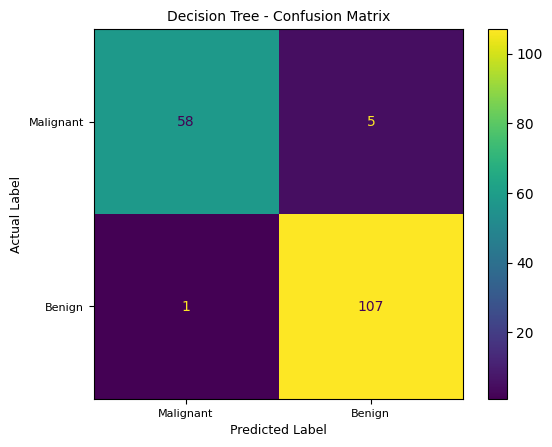

In [117]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler


x = cancer.data
y = cancer.target


x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.3, random_state=42)



minmax = MinMaxScaler()

features = pd.DataFrame(
    cancer.data,
    columns=cancer.feature_names
)



x_train_scaled = minmax.fit_transform(x_train) # doing the feature scaling only for the training dataset
x_test_scaled = minmax.transform(x_test)       # dont to it for testing set bcoz, if you do scaling for testing set, it againa sees the min and max for the testing set and then it scales accordign to that, but we need
                                               # our test dataset to test basd on training dataset right

minmax_df = pd.DataFrame(
    x_train_scaled,
    columns=cancer.feature_names
)


print("Min-Max Scaling on Training Set")
print("===============================")
display(minmax_df)
print(" ")
print(" ")


# Training the model
model1 = LogisticRegression(max_iter=500)
model1.fit(x_train_scaled,y_train)

pred_train = model1.predict(x_train_scaled)
pred_test = model1.predict(x_test_scaled)
print(" ")

from sklearn.metrics import(accuracy_score, precision_score, recall_score, f1_score, confusion_matrix,ConfusionMatrixDisplay)

#Printing Evaluation Metrics - Training Data
print("====================================")
print("Evaluation Metrics for Training Data")
print("====================================")
print("Accuracy : ", accuracy_score(y_train,pred_train))
print("Precision : ", precision_score(y_train,pred_train,average='weighted'))
print("Recall : ", recall_score(y_train,pred_train,average='weighted'))
print("F1 Score : ", f1_score(y_train,pred_train,average='weighted'))


print(" ")
print(" ")


#Printing Evaluation Metrics - Testing Data
print("===================================")
print("Evaluation Metrics for Testing Data")
print("===================================")
print("Accuracy : ", accuracy_score(y_test,pred_test))
print("Precision : ", precision_score(y_test,pred_test,average='weighted'))
print("Recall : ", recall_score(y_test,pred_test,average='weighted'))
print("F1 Score : ", f1_score(y_test,pred_test,average='weighted'))
print("Confusion Matrix :")
cm = confusion_matrix(y_test, pred_test)
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Malignant", "Benign"]
)

disp.plot()

plt.title("Decision Tree - Confusion Matrix", fontsize=10)
plt.xlabel("Predicted Label", fontsize=9)
plt.ylabel("Actual Label", fontsize=9)
plt.xticks(fontsize=8)
plt.yticks(fontsize=8)
plt.show()

#***Decision Tree Model***

UNRESTRICTED DECISION TREE - TRAINING DATA
Accuracy  : 1.0000
Precision : 1.0000
Recall    : 1.0000
F1 Score  : 1.0000


UNRESTRICTED DECISION TREE - TESTING DATA
Accuracy : 0.9415204678362573
Precision: 0.9432896247507402
Recall   : 0.9415204678362573
F1 Score : 0.9418684592468108


Confusion Matrix


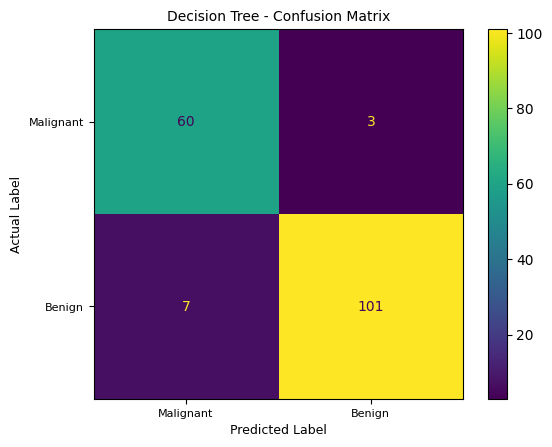

 
 
 
# if you dont give max_depth statement, the decision tree grows on exanding itself and the training set will the learnt many times so while seeign the evaluation metrics it will be 100%
 
 


DECISION TREE (MAX_DEPTH = 5) - TRAINING DATA
Accuracy : 0.9949748743718593
Precision: 0.9950149152135178
Recall   : 0.9949748743718593
F1 Score : 0.9949679478473449


DECISION TREE (MAX_DEPTH = 5) - TESTING DATA
Accuracy : 0.9532163742690059
Precision: 0.9532163742690059
Recall   : 0.9532163742690059
F1 Score : 0.9532163742690059


Confusion Matrix


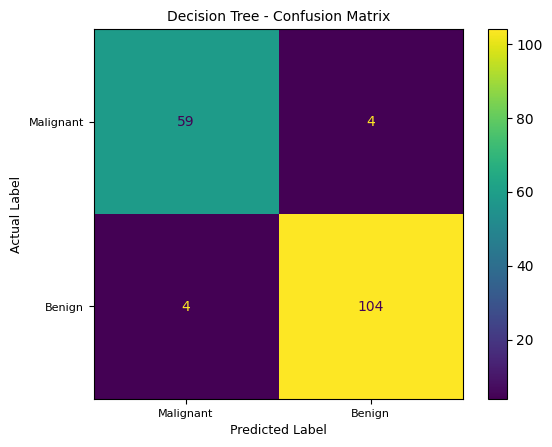

In [119]:
from sklearn.tree import DecisionTreeClassifier

model2_nostop = DecisionTreeClassifier(random_state = 42)
model2_nostop.fit(x_train, y_train)  # for decision tree min_max scaling is not needed, but there is no issue in working on scaled traiing set also
pred_train_nostop = model2_nostop.predict(x_train)
pred_test_nostop = model2_nostop.predict(x_test)



# Unrestricted Decision Tree: the tree is allowed to grow freely without user-defined constraints like max_depth.
# An unrestricted Decision Tree keeps splitting the data freely, which can make it memorize the training data and overfit.


#Printing Evaluation Metrics for Unrestricted Decision Tree - Training Data
print("==========================================")
print("UNRESTRICTED DECISION TREE - TRAINING DATA")
print("==========================================")
print(f"Accuracy  : {accuracy_score(y_train, pred_train_nostop):.4f}")
print(f"Precision : {precision_score(y_train, pred_train_nostop, average='weighted'):.4f}")
print(f"Recall    : {recall_score(y_train, pred_train_nostop, average='weighted'):.4f}")
print(f"F1 Score  : {f1_score(y_train, pred_train_nostop, average='weighted'):.4f}")



#Printing Evaluation Metrics for Unrestricted Decision Tree - Testing Data
print("\n")
print("==========================================")
print("UNRESTRICTED DECISION TREE - TESTING DATA")
print("==========================================")
print("Accuracy :", accuracy_score(y_test, pred_test_nostop))
print("Precision:", precision_score(y_test, pred_test_nostop,average='weighted'))
print("Recall   :", recall_score(y_test, pred_test_nostop,average='weighted'))
print("F1 Score :", f1_score(y_test, pred_test_nostop,average='weighted'))
print("\n")
print("Confusion Matrix")
cm = confusion_matrix(y_test, pred_test_nostop)
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Malignant", "Benign"]
)
disp.plot()
plt.title("Decision Tree - Confusion Matrix", fontsize=10)
plt.xlabel("Predicted Label", fontsize=9)
plt.ylabel("Actual Label", fontsize=9)
plt.xticks(fontsize=8)
plt.yticks(fontsize=8)
plt.show()




print(" ")
print(" ")
print(" ")
print("# if you dont give max_depth statement, the decision tree grows on exanding itself and the training set will the learnt many times so while seeign the evaluation metrics it will be 100%")

print(" ")
print(" ")



model2 = DecisionTreeClassifier(
    max_depth=5,
    random_state=42
)

# if you dont give max_depth statement, the decision tree grows on exanding itself and the training set will the learnt many times so while seeign the evaluation metrics it will be 100%
# lets check both

model2.fit(x_train, y_train)
pred_train = model2.predict(x_train)
pred_test = model2.predict(x_test)



#Printing Evaluation Metrics for Restricted Decision Tree - Training Data
print("\n")
print("=============================================")
print("DECISION TREE (MAX_DEPTH = 5) - TRAINING DATA")
print("=============================================")
print("Accuracy :", accuracy_score(y_train, pred_train))
print("Precision:", precision_score(y_train, pred_train,average='weighted'))
print("Recall   :", recall_score(y_train, pred_train,average='weighted'))
print("F1 Score :", f1_score(y_train, pred_train,average='weighted'))




#Printing Evaluation Metrics for Restricted Decision Tree - Testing Data
print("\n")
print("============================================")
print("DECISION TREE (MAX_DEPTH = 5) - TESTING DATA")
print("============================================")
print("Accuracy :", accuracy_score(y_test, pred_test))
print("Precision:", precision_score(y_test, pred_test,average='weighted'))
print("Recall   :", recall_score(y_test, pred_test,average='weighted'))
print("F1 Score :", f1_score(y_test, pred_test,average='weighted'))
print("\n")
print("Confusion Matrix")
cm = confusion_matrix(y_test, pred_test)
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Malignant", "Benign"]
)

disp.plot()

plt.title("Decision Tree - Confusion Matrix", fontsize=10)
plt.xlabel("Predicted Label", fontsize=9)
plt.ylabel("Actual Label", fontsize=9)
plt.xticks(fontsize=8)
plt.yticks(fontsize=8)
plt.show()